### Libraries

In [1]:
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter

## Load data

In [60]:
# df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]      #Local dataset
# df_ch.head(2)

# # Renaming the columns
# data = df_ch[['BMI', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'ListCat', 'ED5B', 'HL4', 'HH6', 'AN8', 'AN4', 'CA14', 'CA1', 'BD2', 'WAZ2', 'HAZ2', 'WHZ2']]
# df1 = data.rename(columns={
#     'AN4': 'child_age',
#     'AN8': 'child_weight',
#     'BD2': 'ever_breastfed',
#     'CA1': 'diarrhoea_last_2_weeks',
#     'CA14': 'fever_last_2_weeks',
#     'HH6': 'area',
#     'HL4': 'child_sex',
#     'melevel1': 'mother_education',
#     'cinsurance': 'health_insurance',
#     'HH7c': 'province',
#     'BMI': "BMI",
#     'ListCat': 'Under5child',
#     'ED5B': 'Highest_class',
#     'windex5': 'wealth_index',
#     'WAZ2': 'underweight',
#     'HAZ2': 'stunting',
#     'WHZ2': 'wasting'
# })

# # Remove rows with coded entries in each column
# coded_child_age = [99.6, 99.5, 99.4, 99.3]
# coded_underweight = [99.99, 99.98, 99.97]
# coded_stunting = [99.99, 99.98, 99.97]
# coded_wasting = [99.97]
# coded_diarrhoea = [9, 8]
# coded_fever = [8]
# coded_insurance = [9]
# coded_breastfed = [9]
# coded_BMI = [99.99]
# coded_highest = [99, 98]

# df1 = df1[~df1['child_age'].isin(coded_child_age)]
# df1 = df1[~df1['underweight'].isin(coded_underweight)]
# df1 = df1[~df1['stunting'].isin(coded_stunting)]
# df1 = df1[~df1['wasting'].isin(coded_wasting)] 
# df1 = df1[~df1['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
# df1 = df1[~df1['fever_last_2_weeks'].isin(coded_fever)]
# df1 = df1[~df1['health_insurance'].isin(coded_insurance)]
# df1 = df1[~df1['ever_breastfed'].isin(coded_breastfed)]
# df1 = df1[~df1['BMI'].isin(coded_BMI)]
# df1 = df1[~df1['Highest_class'].isin(coded_highest)]

# df1 = df1.dropna()
# df1.isna().sum()

# # Convert to Binary Response Variables
# df2 = df1.copy()
# df2['underweight'] = [0 if -2 <= x < 2 else 1 for x in df2['underweight']]
# df2['stunting'] = [0 if -2 <= x < 2 else 1 for x in df2['stunting']]
# df2['wasting'] = [0 if -2 <= x < 2 else 1 for x in df2['wasting']]

# # Change binary features from 1/2 to 1/0
# df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({2: 0})

# df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
# df3 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# # Standardize childe weight
# scaler = StandardScaler()
# df3[['BMI', 'child_weight']] = scaler.fit_transform(df3[['BMI', 'child_weight']])

# # Separate features and target
# df= df3.copy()
# X = df.drop(columns='malnurished')
# y = df['malnurished']

# # Optional: Scale only continuous features (child_weight)
# scaler = StandardScaler()
# X['child_weight'] = scaler.fit_transform(X[['child_weight']])

# # Convert to numpy arrays (Boruta requires numpy arrays)
# X_np = X.values
# y_np = y.values

# # Define the RandomForest model for Boruta
# rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# # Initialize Boruta
# boruta_selector = BorutaPy(
#     estimator=rf,
#     n_estimators='auto',
#     verbose=2,
#     random_state=42
# )

# # Fit Boruta
# boruta_selector.fit(X_np, y_np)

# # Get selected feature names
# selected_features = X.columns[boruta_selector.support_].tolist()
# print("Selected Features by Boruta:")
# print(selected_features)

# df = df3[['BMI', 'province', 'Highest_class', 'child_weight', 'child_age', 'malnurished']]


# # Convert all columns except 'child_weight' to integer
# cols_to_convert = df.columns.difference(['child_weight'])
# df[cols_to_convert] = df[cols_to_convert].astype(int)

# df.head(2)

# X = df.drop(columns=['malnurished'])
# y = df['malnurished']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

In [55]:
df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]      #Local dataset
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,2.0,3.0,1.0,1.0,11.1,1.1
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,1.0,2.0,1.0,1.0,11.1,1.1


## Rename variables and remove the coded entries

In [56]:
# Renaming the columns
feature_coded = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = feature_coded.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df1 = df1[~df1['child_age'].isin(coded_child_age)]
df1 = df1[~df1['underweight'].isin(coded_underweight)]
df1 = df1[~df1['stunting'].isin(coded_stunting)]
df1 = df1[~df1['wasting'].isin(coded_wasting)] 
df1 = df1[~df1['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df1 = df1[~df1['fever_last_2_weeks'].isin(coded_fever)]
df1 = df1[~df1['health_insurance'].isin(coded_insurance)]
df1 = df1[~df1['ever_breastfed'].isin(coded_breastfed)]
df1.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,underweight,stunting,wasting
0,1.0,7.8,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,-2.94,-3.53,-1.69
1,3.0,12.5,NaN,2.0,1.0,2.0,1.0,5.0,2.0,1.0,1.0,-1.93,-2.58,-0.65


## Convert response variable to binary class

Accroding to WHO ...

In [5]:
# Convert to Binary Response Variables
df2 = df1.copy()
df2['underweight'] = [0 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [0 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [0 if -2 <= x < 2 else 1 for x in df2['wasting']]

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({2: 0})

df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,underweight,stunting,wasting
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1,1,0
1,3.0,12.5,NaN,0.0,1.0,0.0,1.0,5.0,0.0,1.0,1.0,0,1,0


## Create 'malnurished' as response variable

In [6]:
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df3 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)
df3.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
1,3.0,12.5,NaN,0.0,1.0,0.0,1.0,5.0,0.0,1.0,1.0,1


## Standardize continuous feature

In [7]:
# Standardize childe weight
scaler = StandardScaler()
df3['child_weight'] = scaler.fit_transform(df3[['child_weight']])

### One-hot encode to nominal feature

In [8]:
# One-hot encode to province
df4 = pd.get_dummies(df3, columns=['province'], drop_first=False)
df4.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1.0,-1.085628,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1,True,False,False,False,False,False,False
1,3.0,0.420314,NaN,0.0,1.0,0.0,1.0,5.0,0.0,1.0,1,True,False,False,False,False,False,False


In [9]:
df4.isna().sum()

child_age                   91
child_weight                91
ever_breastfed            2940
diarrhoea_last_2_weeks      91
fever_last_2_weeks          91
area                         0
child_sex                    0
mother_education            91
health_insurance            91
wealth_index                 0
malnurished                  0
province_1.0                 0
province_2.0                 0
province_3.0                 0
province_4.0                 0
province_5.0                 0
province_6.0                 0
province_7.0                 0
dtype: int64

### Drop ever breastfed and missing entries

Ever breastfed has 2940 missing entries and this variable has very weak significance supported by cramer's v test and feature importance check.

In [10]:
df5 = df4.drop(columns=['ever_breastfed'])

# Drop missing values and make a copy to avoid chained assignment issues
df = df5.dropna().copy()

# Convert all columns except 'child_weight' to integer
cols_to_convert = df.columns.difference(['child_weight'])
df[cols_to_convert] = df[cols_to_convert].astype(int)

df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


In [11]:
print(df1.shape)
print(df.shape)
print(df['malnurished'].value_counts())

(6521, 14)
(6430, 17)
malnurished
0    3535
1    2895
Name: count, dtype: int64


## Childern counts vs malnutrition status

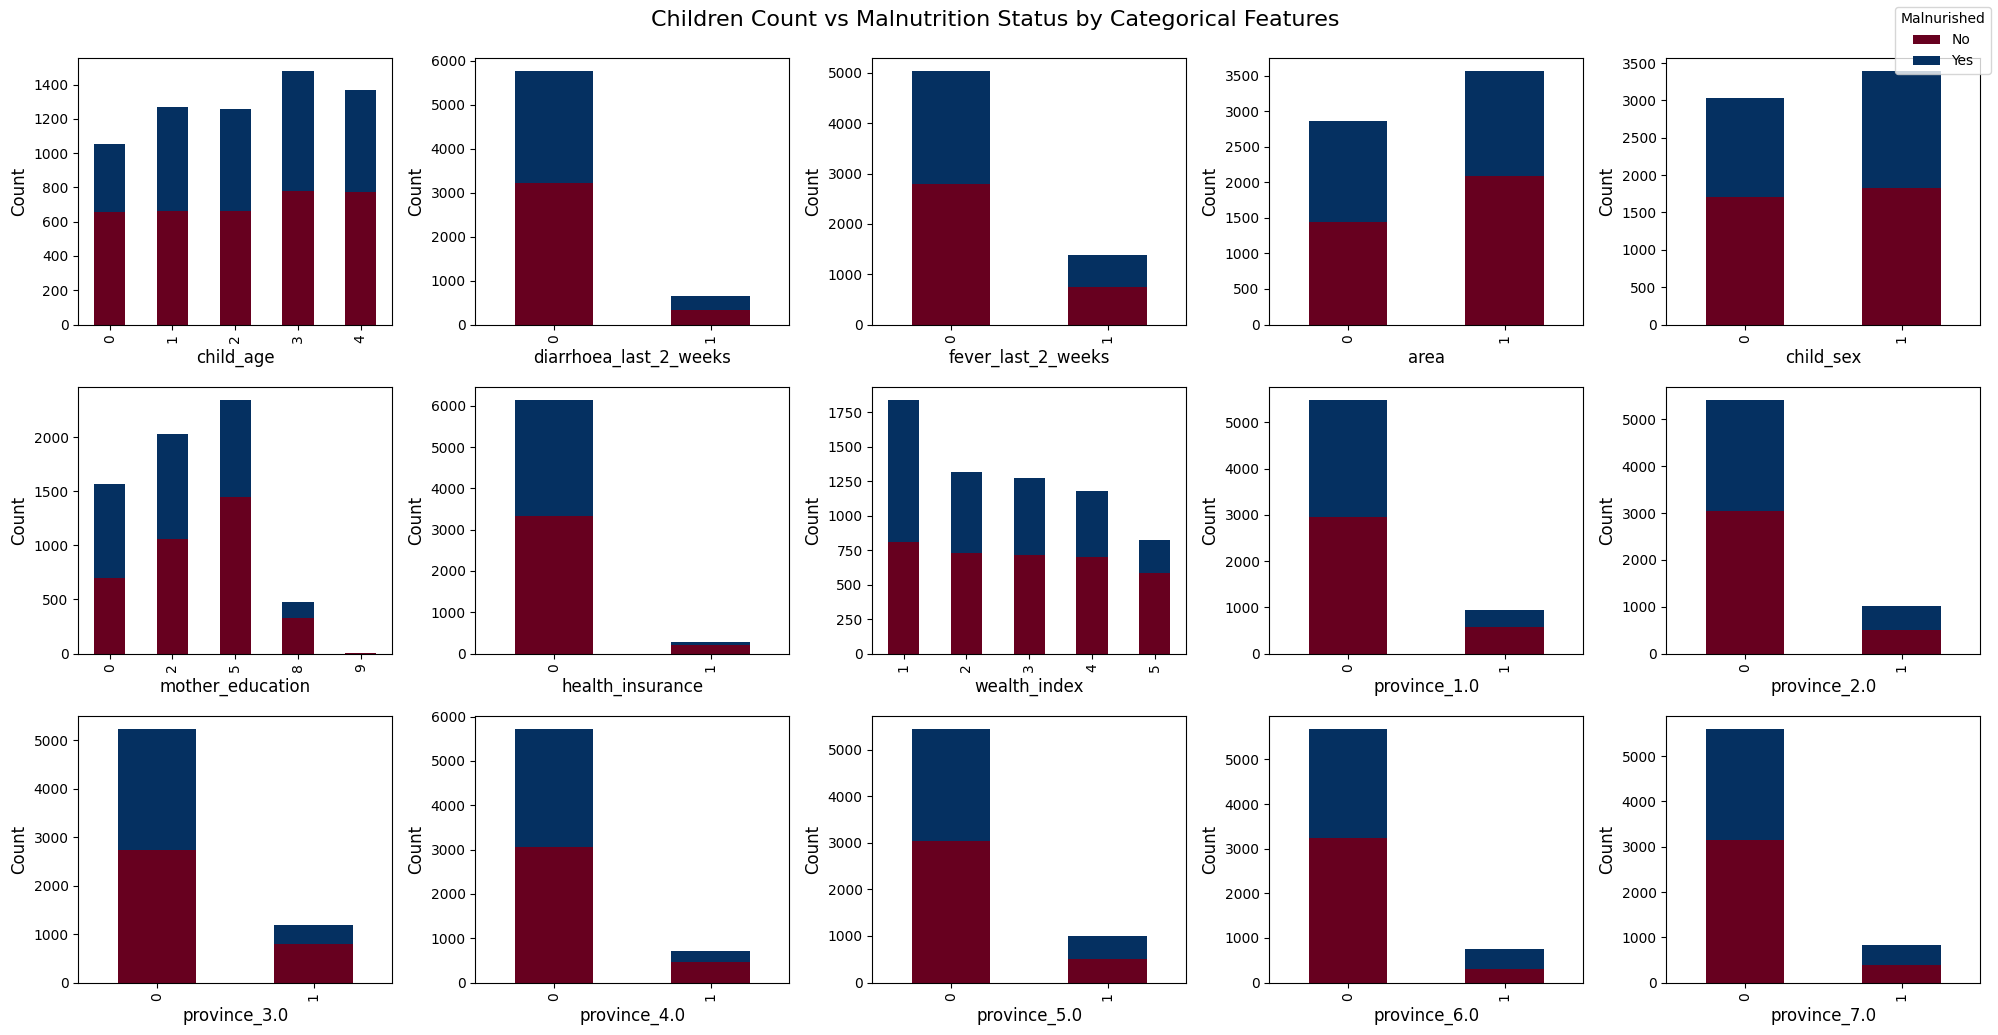

In [12]:
# List of features to plot
features = [
    'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'wealth_index',     
    'province_1.0',	'province_2.0',	'province_3.0',	'province_4.0',	'province_5.0',	'province_6.0',	'province_7.0'
]

# Set up a grid for 2 rows × 4 columns
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, feature in enumerate(features):
    ctab = pd.crosstab(df[feature], df['malnurished'])
    ctab.plot(kind='bar', stacked=True, colormap='RdBu', ax=axes[i], legend=False)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=12)

# Add one global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No', 'Yes'], title='Malnurished', loc='upper right')

plt.tight_layout()
plt.suptitle("Children Count vs Malnutrition Status by Categorical Features", fontsize=16, y=1.03)
plt.show()

### Violinplot of continuous feature

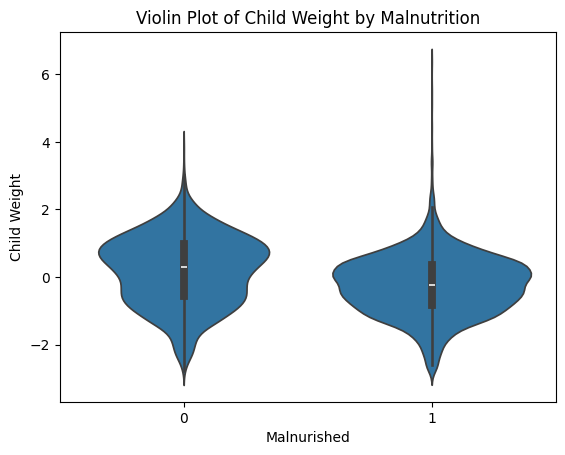

In [13]:
sns.violinplot(x='malnurished', y='child_weight', data=df)
plt.title("Violin Plot of Child Weight by Malnutrition")
plt.xlabel("Malnurished")
plt.ylabel("Child Weight")
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [14]:
# Listing all categorical features
cat_columns = [
    'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'wealth_index',     
    'province_1.0',	'province_2.0',	'province_3.0',	'province_4.0',	'province_5.0',	'province_6.0',	'province_7.0'
]

# Contingency table for categorical features
contingency_tables = {}
for col in cat_columns:
    contingency_tables[col] = pd.crosstab(df[col], df['malnurished'])
    print(f"Contingency table for {col}:\n{contingency_tables[col]}\n")

Contingency table for child_age:
malnurished    0    1
child_age            
0            657  395
1            663  606
2            665  595
3            777  703
4            773  596

Contingency table for diarrhoea_last_2_weeks:
malnurished                0     1
diarrhoea_last_2_weeks            
0                       3210  2562
1                        325   333

Contingency table for fever_last_2_weeks:
malnurished            0     1
fever_last_2_weeks            
0                   2788  2253
1                    747   642

Contingency table for area:
malnurished     0     1
area                   
0            1445  1416
1            2090  1479

Contingency table for child_sex:
malnurished     0     1
child_sex              
0            1711  1324
1            1824  1571

Contingency table for mother_education:
malnurished          0    1
mother_education           
0                  699  872
2                 1058  973
5                 1447  898
8                  330 

In [15]:
X_cat = df[cat_columns].copy()
y = df['malnurished']

# Label encode all categorical variables if needed
for col in X_cat.columns:
    if X_cat[col].dtype == 'object':
        X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

chi_vals, p_vals = chi2(X_cat, y)

chi_df = pd.DataFrame({'Feature': X_cat.columns, 'Chi2': chi_vals, 'p-value': p_vals})
print(chi_df.sort_values(by='Chi2', ascending=False))


                   Feature        Chi2       p-value
5         mother_education  293.484496  8.656283e-66
7             wealth_index  117.909050  1.815237e-27
10            province_3.0   74.305271  6.692458e-18
13            province_6.0   65.678714  5.307602e-16
11            province_4.0   36.471312  1.549298e-09
14            province_7.0   24.059982  9.338092e-07
6         health_insurance   22.926919  1.682787e-06
3                     area   18.512292  1.688120e-05
9             province_2.0   13.637560  2.217054e-04
8             province_1.0   12.684522  3.686949e-04
1   diarrhoea_last_2_weeks    8.290678  3.984911e-03
12            province_5.0    7.807891  5.201857e-03
0                child_age    4.143135  4.180367e-02
4                child_sex    2.145179  1.430184e-01
2       fever_last_2_weeks    0.804000  3.699003e-01


### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [25]:
cramers_v_results = {}

for col in cat_columns:
    if col != 'malnurished':
        table = pd.crosstab(df[col], df['malnurished'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        # print(f"{col}: Cramér's V = {V:.4f}")

cramers_v_sorted = pd.Series(cramers_v_results).sort_values(ascending=False)
print(cramers_v_sorted)

wealth_index              0.166907
mother_education          0.156171
province_3.0              0.118713
province_6.0              0.107006
area                      0.080125
province_4.0              0.079359
child_age                 0.073704
province_7.0              0.065081
health_insurance          0.060354
province_2.0              0.049761
province_1.0              0.047648
province_5.0              0.037448
diarrhoea_last_2_weeks    0.037384
child_sex                 0.026273
fever_last_2_weeks        0.012249
dtype: float64


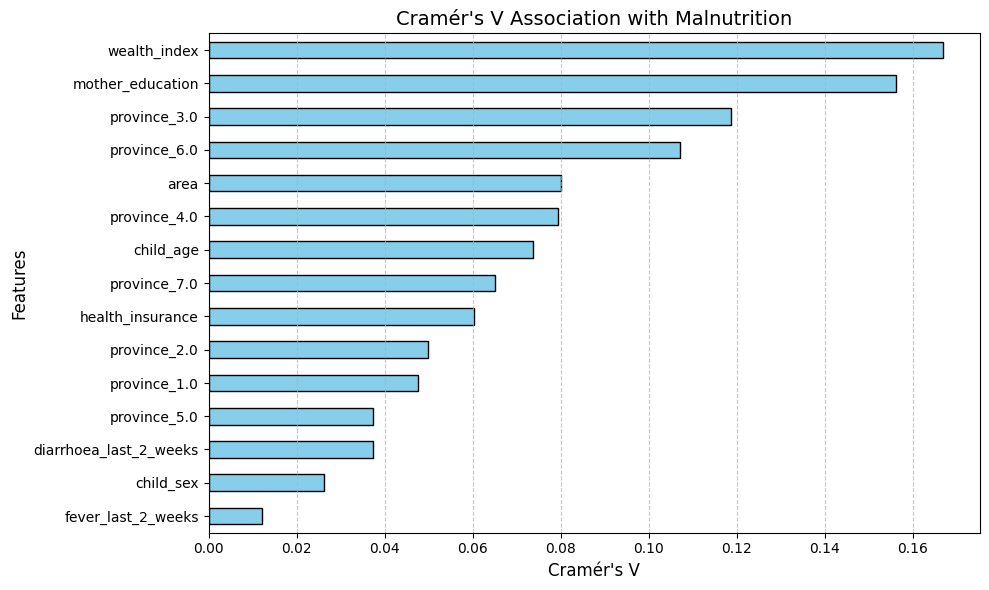

In [26]:
# Plotting the sorted Cramér's V values
plt.figure(figsize=(10, 6))
cramers_v_sorted.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title("Cramér's V Association with Malnutrition", fontsize=14)
plt.xlabel("Cramér's V", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Data visualization

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


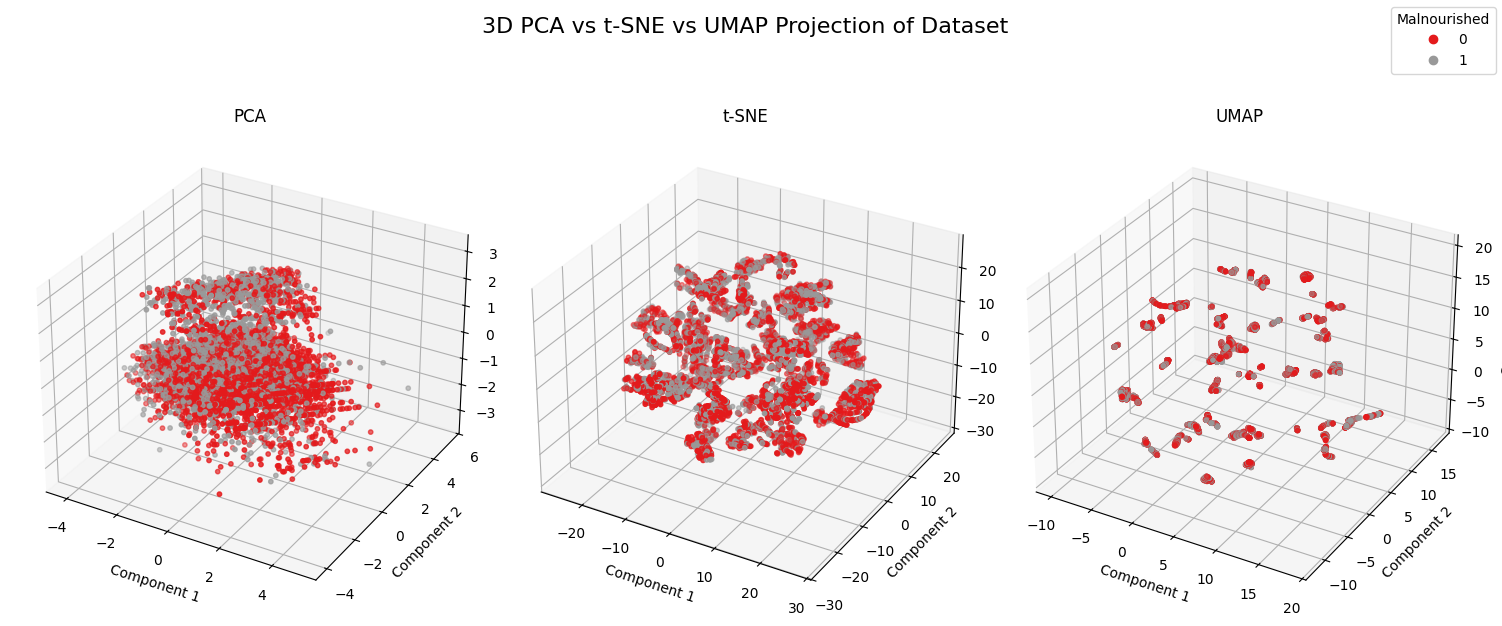

In [53]:
# Encode and scale the dataset
X = pd.get_dummies(df.drop(columns='malnurished'), drop_first=True)
y = df['malnurished']
X_scaled = StandardScaler().fit_transform(X)

# Reduce with PCA (3D)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Reduce with t-SNE (3D)
X_tsne = TSNE(n_components=3, random_state=42).fit_transform(X_scaled)

# Reduce with UMAP (3D)
X_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(15, 7))

# PCA
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='Set1', s=10)
ax1.set_title("PCA")
ax1.set_xlabel("Component 1")
ax1.set_ylabel("Component 2")
ax1.set_zlabel("Component 3")

# t-SNE
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y, cmap='Set1', s=10)
ax2.set_title("t-SNE")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.set_zlabel("Component 3")

# UMAP
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=y, cmap='Set1', s=10)
ax3.set_title("UMAP")
ax3.set_xlabel("Component 1")
ax3.set_ylabel("Component 2")
ax3.set_zlabel("Component 3")

# Legend (common)
fig.legend(*scatter1.legend_elements(), title="Malnourished", loc="upper right")
fig.suptitle("3D PCA vs t-SNE vs UMAP Projection of Dataset", fontsize=16)
plt.tight_layout()
plt.show()

## Save final data

In [ ]:
# df.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv', index=False)

---

## Boruta Algorithm for feature selection

In [ ]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = df.drop(columns='malnurished')
y = df['malnurished']

# Convert to numpy arrays (Boruta requires numpy arrays)
X_np = X.values
y_np = y.values

# Define the RandomForest model for Boruta
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Fit Boruta
boruta_selector.fit(X_np, y_np)

# Get selected feature names
selected_features = X.columns[boruta_selector.support_].tolist()
print("✅ Selected Features by Boruta:")
print(selected_features)